In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
import warnings
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import swifter
from matplotlib.colors import LinearSegmentedColormap
sys.path.append('../')
pd.options.mode.chained_assignment = None 



In [25]:
#DISTANCE THRESHOLD
#used to classify an event as entering or exiting
#when two consecutive detections of the same event 
#have this distance in y position, they are utilized to predict
#the trajectory. If not then it checks the detection prior for
#the distance threshold, and continues doing so until it finds
#the last detection in the event or until it finds a distance
#of more than the threshold

t2 = 150

#ANGLE THRESHOLD
#used to generate angle ranges for classifying as exiting
#or entering

angle = 10
order = ['entering','exiting','entering-exiting','exiting-entering','unknown']

In [3]:
#combine all CSV's of the same data
files = open("bees/files.txt")
filenames = []
while True:
    line = files.readline().strip()
    if not line:
        break
    filenames.append("bees/" + line)

vdf = pd.concat(map(pd.read_csv, filenames), ignore_index=True)

In [4]:
df = vdf.copy()

In [5]:

vdf = df.copy()

In [6]:
vdf['track_starttime'] = pd.to_datetime(vdf['track_starttime'])
vdf['track_endtime'] = pd.to_datetime(vdf['track_endtime'])
#fill missing tagids
#vdf['track_tagid'] = (
#    vdf.groupby(['video_name', 'track_id'])['track_tagid']
#      .transform(lambda s: s.ffill().bfill())
#)
#vdf.fillna(method='ffill', inplace=True)
#vdf = vdf.sort_values(by=['track_tagid','track_tagid'])




In [7]:
def groupbyseconds(vdf,sec):
    tracks = (vdf.groupby(['track_id','track_tagid'], as_index=False)
            .agg(start=('track_starttime','min'),
                 end=('track_endtime','max')))


    #sort by video name, track id and start
    tracks = tracks.sort_values(['track_tagid','start'])
    
    
    #obtain breakpoints of 5 second gaps
    tracks['gap_s'] = (
        tracks['start'] - tracks.groupby(['track_tagid'])['end'].shift(1)
    ).dt.total_seconds()

    #mark as breakpoints
    tracks['split'] = tracks['gap_s'].isna() | (tracks['gap_s'] > sec) | (tracks['gap_s'] < 0)
    
    #segment to obtain track values by individual ids
    tracks['segment'] = tracks.groupby(['track_tagid'])['split'].cumsum()
    
    #group by unique ids and tracks
    tracks['group_id'] = tracks.groupby(['track_tagid', 'segment']).ngroup()

    group_members = (
        tracks.groupby(['track_tagid', 'group_id'])['track_id']
        .apply(lambda s: tuple(sorted(s)))
        .reset_index(name='members')
    )

    # stable group_id: tagid + exact member list
    group_members['global_id'] = group_members.apply(
        lambda row: f"{row['track_tagid']}__{'_'.join(map(str, row['members']))}",
        axis=1
    )

    tracks = tracks.merge(
        group_members[['track_tagid', 'group_id', 'global_id']],
        on=['track_tagid', 'group_id'],
        how='left'
    )
    
    vdf = vdf.merge(
        tracks[['track_id', 'track_tagid','global_id','group_id']],
        on=['track_id','track_tagid'],
        how='left'
    )
    vdf = vdf.dropna(subset=['group_id'])

    return vdf

In [9]:
vdf = groupbyseconds(vdf,5)

In [10]:
len(vdf['group_id'].unique())

22820

## RULES

In [11]:
####CLASSIFICATION AS ENTERING-EXITING OR EXITING-ENTERING

def displacement(data):  

        #convert to numpy for speed
        y = data["cy"].to_numpy()
        #assign final and obtain all differences
        final = y[-1]
        diff = y - final

        #obtain all values where it surpasses the threshold
        idx = np.where(np.abs(diff) >= t2)[0]
        #extract only the last one
        cur = diff[idx[-1]] if idx.size else diff[0]

        if cur > 0:
            return "exiting"
        elif cur < 0:
            return "entering"
        else:
            return "unknown"

def displacement2(data):            
        #convert to numpy for speed
        y = data["cy"].to_numpy()
        #assign first and obtain all differences
        first = y[0]
        diff = y - first

        #obtain all values where it surpasses the threshold
        idx = np.where(np.abs(diff) >= t2)[0]
        #extract only the first one
        cur = diff[idx[0]] if idx.size else diff[0]

        if cur < 0:
            return 'exiting'
        elif cur > 0:
            return 'entering'
        else:
            return 'unknown'

def getangle(coordinates):
    exit_min = 180 + angle
    exit_max = 360 - angle
    enter_min = angle
    enter_max = 180 - angle

    #normalize angle from -180 to 180 to 0 to 360
    deg = coordinates % 360

    if deg >= exit_min and deg <= exit_max:
        return 'exiting'
    elif deg >= enter_min and deg <= enter_max:
        return 'entering'
    else:
        return 'unknown'

#RULE 1 ITERATE BACKWARDS AND FORWARDS DISPLACEMENT
def displacementbackforth(data):   


        string2 = displacement(data)
        string = displacement2(data)

        #if both directions are the same, return value
        #else return compound event
        return string if string == string2 else f"{string}-{string2}"
        

#RULE 2 FIRST AND LAST DIRECTIONAL ANGLE
    

def lastfirstangle(data):

    if len(data) > 0:
        coordinates = data['angle'].iloc[-1]
    
        string2 = getangle(coordinates)
    
        coordinates = data['angle'].iloc[0]
    
        string = getangle(coordinates)
    
        return string if string == string2 else f"{string}-{string2}"
    else:
        return 'unknown'

#RULE 3 THRESHOLD BIDIRECTIONAL
def in_out2(data):
    if data['cy'].iloc[0] < 450 and data['cy'].iloc[-1] > 600 or (450 < data['cy'].iloc[0] < 600 and data['cy'].iloc[-1] > 600):
        return "entering"
    if (data['cy'].iloc[0] > 600 and data['cy'].iloc[-1] < 600) or (450 < data['cy'].iloc[0] < 600 and data['cy'].iloc[-1] < 450):
        return "exiting"
    if data['cy'].iloc[0] < 450 and data['cy'].iloc[-1] < 450:
        return "entering-exiting"
    if data['cy'].iloc[0] > 600 and data['cy'].iloc[-1] > 600:
        return "exiting-entering"
    return 'unknown'

        


In [34]:
vdf.columns

Index(['Unnamed: 0', 'frame', 'det_id', 'track_id', 'tag_id', 'video_name',
       'cx', 'cy', 'angle', 'virtual', 'tag_hamming', 'tag_dm', 'tag_cx',
       'tag_cy', 'score', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
       'bbox_confidence', 'head_x', 'head_y', 'head_conf', 'head_visibility',
       'neck_x', 'neck_y', 'neck_conf', 'neck_visibility', 'thorax_x',
       'thorax_y', 'thorax_conf', 'thorax_visibility', 'waist_x', 'waist_y',
       'waist_conf', 'waist_visibility', 'tail_x', 'tail_y', 'tail_conf',
       'tail_visibility', 'waist_src', 'angle_src', 'vx', 'vy', 'cost', 'pcx',
       'pcy', 'pa', 'pvx', 'pvy', 'tag_goodness', 'tag_p0x', 'tag_p0y',
       'tag_p1x', 'tag_p1y', 'tag_p2x', 'tag_p2y', 'tag_p3x', 'tag_p3y',
       'tag_H', 'tag_dx', 'tag_dy', 'tag_ntags', 'timestamp', 'track_shape',
       'track_event', 'track_startframe', 'track_startx', 'track_starty',
       'track_starta', 'track_endframe', 'track_endx', 'track_endy',
       'track_enda', 'track_len

In [12]:
results = {'tagID':[],'datetime':[],'event':[]}
for group_id, detections in vdf.groupby('group_id'):
        results['event'].append(in_out2(detections))
        results['tagID'].append(detections['track_tagid'].iloc[-1])
        results['datetime'].append(detections['track_endtime'].iloc[-1])

res = pd.DataFrame.from_dict(results)

        

In [13]:
res.to_csv("allBees.csv",index=False)

In [18]:
res['hour'] = res['datetime'].dt.hour
res['day'] = res['datetime'].dt.day

res2 = res[res['day'] > 27]

<Axes: xlabel='hour', ylabel='Count'>

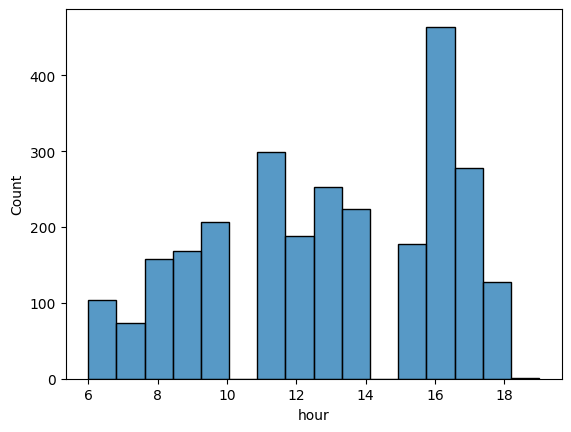

In [19]:
sns.histplot(data=res2,x='hour')

In [22]:
res2['hour'].value_counts()

hour
16    464
11    299
17    278
13    253
14    224
10    206
12    188
15    178
9     168
8     158
18    127
6     104
7      73
19      1
Name: count, dtype: int64

In [36]:
res['tagID'].unique()

array([  25,  184,  259, ..., 1591, 1824, 1939], shape=(1119,))

In [37]:
#classify all events
events = vdf['group_id'].unique()

functions = {
    'THRS_BIDIR':in_out2,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}

for_matrix2 = {key: [] for key in functions}

unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']

for group_id, detections in vdf.groupby('group_id'):
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix2[APPROACHES].append(result)



In [38]:
#generates graphs of distribution of classes
#label is used for the name of the file i.e. 'simple', 'compound'
def generate_dist(the_matrix,label):
    the_df = []
    for c in the_matrix.columns:
        column = the_matrix[c]
        values = column.value_counts()
        df = values.rename("count").reset_index()
        df["algo"] = c
        df = df.rename(columns={df.columns[0]:'event'})
        the_df.append(df)
    full_df = pd.concat(the_df, ignore_index=True)

    stacked = full_df.pivot_table(
    index="algo", 
    columns="event", 
    values="count",
    fill_value=0
    )
    stacked = stacked.reindex(the_matrix.columns)
    num_cols = stacked.shape[1]
    if(num_cols > 3):
        stacked = stacked.reindex(columns=order)

    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(stacked))

    for event in stacked.columns:
        values = stacked[event].values

        bars = ax.bar(
            stacked.index,
            values,
            bottom=bottom,
            edgecolor="white",
            label=event,
            color=distpalette.get(event)
        )

        bottom += values

    ax.legend(
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=16, title_fontsize=14
    )

    ax.tick_params(axis='both', labelsize=16)
    ax.tick_params(axis='x', labelrotation=90)
    ax.grid(True, axis="y", color="gray", alpha=0.5) 
    ax.set_ylabel("Count")
    ax.set_axisbelow(True)
    ax.set_xlabel("Algorithm")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    fig.savefig(f"{label}-count.png",bbox_inches='tight',bbox_extra_artists=(ax.get_legend(),)) 

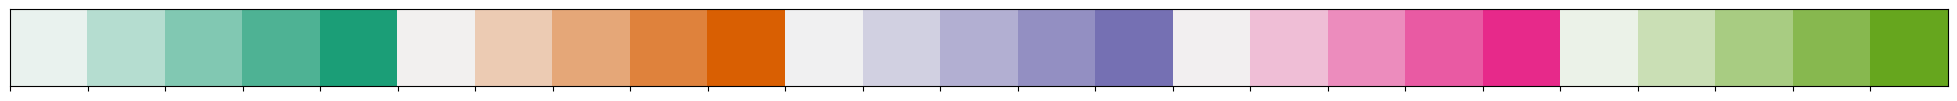

In [39]:
colors =['#1B9E77','#D95F02','#7570B3','#E7298A','#66A61E']
full_palette = sns.color_palette(colors)
sns.set_palette(full_palette)
cmap = LinearSegmentedColormap.from_list("custom_cmap", full_palette)
third_class = 'unknown'
expanded_palette = []

for color in colors:
    shades = sns.light_palette(color, n_colors=5)
    expanded_palette.extend(shades)

expanded_palette
sns.palplot(expanded_palette)

In [40]:
distpalette = {
    "entering": expanded_palette[4],
    "exiting": expanded_palette[9],
    "entering-exiting": expanded_palette[14],
    "exiting-entering": expanded_palette[19],
    "unknown": expanded_palette[24]
}

In [41]:
palette = {
    "THRS_BIDIR":    expanded_palette[4],
    "BEE_ANG_BIDIR": expanded_palette[9],
    "DISP_BIDIR":expanded_palette[24],
}

In [42]:
compound_matrix = pd.DataFrame.from_dict(for_matrix2)
#generate_dist(compound_matrix,"full")

In [43]:
compound = ['exiting-entering','entering-exiting']
for k in compound_matrix.columns:
    col = compound_matrix[k]
    print(k)
    print(col.isin(compound).sum())

THRS_BIDIR
7902
DISP_BIDIR
5672
BEE_ANG_BIDIR
5552


In [44]:
def fixDate(x):
    month = x.month
    day = x.day
    if day < 10:
        day = f'0{day}'
    return f'{month}/{day}'

In [45]:
#classify all events with thrs_bidir for date separation
events = vdf['group_id'].unique()
thrs_bidir = {'classification':[], 'date':[]}


for group_id, detections in vdf.groupby('group_id'):
    result = in_out2(detections)
    thrs_bidir['classification'].append(result)
    thrs_bidir['date'].append(fixDate(detections['track_starttime'].iloc[0]))



In [46]:
thrs_bidir = pd.DataFrame.from_dict(thrs_bidir)
thrs_bidir

,classification,date
0,exiting,8/13
1,exiting,8/13
2,entering-exiting,8/13
3,entering,8/13
4,entering,8/13
...,...,...
21831,entering,8/09
21832,exiting-entering,8/09
21833,entering,8/09
21834,exiting,8/09


In [47]:
len(events)

21837

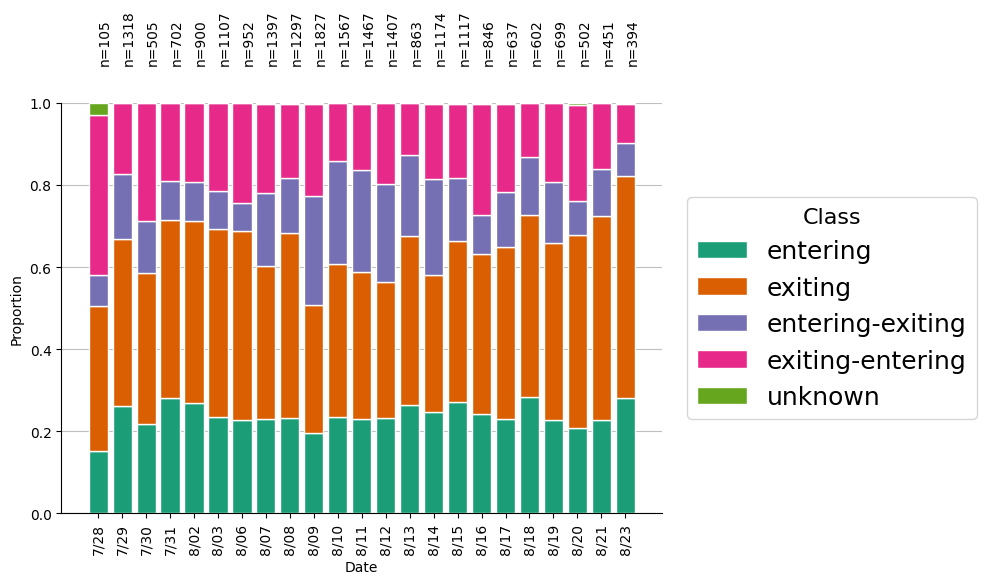

In [48]:
count = thrs_bidir.groupby(['date','classification']).size().rename("count").reset_index()
count["count"] = count["count"]/count.groupby('date')['count'].transform("sum")
totalCount = thrs_bidir.groupby(['date']).size()
stacked = count.pivot_table(
    index="date", 
    columns="classification", 
    values="count",
    fill_value=0
    )
stacked = stacked.reindex(columns=order)
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(stacked))

for event in stacked.columns:
    values = stacked[event].values

    bars = ax.bar(
        stacked.index,
        values,
        bottom=bottom,
        edgecolor="white",
        label=event,
        color=distpalette.get(event)
    )

    bottom += values

texts = []
for i, date in enumerate(stacked.index):
    txt = ax.text(
        i,
        1.1,
        f'n={totalCount.iloc[i]}',
        fontsize=10,
        rotation="vertical",
        clip_on=False
    )
    texts.append(txt)


ax.legend(
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=18, title_fontsize=16
    )


ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, axis="y", color="gray", alpha=0.5) 
ax.set_ylabel("Proportion")
ax.set_axisbelow(True)
ax.set_xlabel("Date")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig(f"THRS_BIDIR_count.png",bbox_inches='tight',bbox_extra_artists=(ax.get_legend(),*texts)) 

In [49]:
count[count['classification'] == "unknown"]['count'].mean()

np.float64(0.003954152022957378)

In [50]:
count[count['classification'] == "unknown"]['count'].median()

np.float64(0.001747043904105515)

In [51]:
len(thrs_bidir[thrs_bidir['classification'] == 'entering-exiting'])

3697

In [52]:
len(thrs_bidir[thrs_bidir['classification'] == 'exiting-entering'])

4205

In [54]:
len(thrs_bidir['classification'])

21836